## REPORT FOR WEEK 4 REPORT 
### THE VALUE OF THE PARAMETERS ARE MENTIONED BELOW 

S0 = 100
k = 100
r = 0.05
sigma = 0.25
T = 1.0
stePs = 500

 american = True implies if you want american puts price and european puts option otherwise

| **Parameter**          | **Explanation**                                                                                                                                                                      |
| ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **S0**                 | The initial stock price at the beginning of the option's life. It is the starting point from which all future stock prices are calculated.                                           |
| **K**                  | The strike price of the option. It is the fixed price at which the option holder has the right to sell the stock.                                                                    |
| **T**                  | The total time until the option expires, usually measured in years.                                                                                                                  |
| **r**                  | The risk free interest rate used to discount future option values back to their present value.                                                                                       |
| **sigma**              | The volatility of the stock price. It measures how much the stock price is expected to fluctuate over time.                                                                          |
| **steps**              | The number of time intervals used to divide the option's life. A larger number of steps generally produces a more accurate option price.                                             |
| **dt**                 | The length of one time step. It is calculated as the total time divided by the number of steps.                                                                                      |
| **u**                  | The up movement factor. It shows how much the stock price increases during one time step when the market moves upward.                                                               |
| **d**                  | The down movement factor. It shows how much the stock price decreases during one time step when the market moves downward. It is calculated as the reciprocal of the up factor.      |
| **growth**             | The expected growth of money over one time step at the risk free interest rate. It is used while computing the probability under the risk neutral model.                             |
| **p**                  | The risk neutral probability of an upward movement in the stock price. It is not the actual market probability but a mathematical probability used for option pricing.               |
| **disc**               | The discount factor used to convert future option values into their present value at each time step.                                                                                 |
| **stock**              | An array containing the stock prices at different nodes of the binomial tree. These prices are generated using the up and down movement factors.                                     |
| **value**              | The option value at each node of the tree. It is updated by moving backward from the maturity date to the present.                                                                   |
| **exercise**           | The immediate payoff obtained by exercising the American put option at a particular node. It is compared with the continuation value to decide whether early exercise is beneficial. |
| **continuation value** | The expected value of holding the option instead of exercising it immediately. It is calculated using the discounted expected future option values.                                  |
| **American**           | A Boolean parameter that determines whether early exercise is allowed. If it is set to True, the model prices an American option. Otherwise, it prices a European option.            |


In [13]:
import math 
import numpy as np 

def crr_put_price(
        S0: float ,
        K: float,
        T: float,
        r: float,
        sigma: float,
        steps: int,
        american: bool
        ):
    if S0 <= 0 or K <= 0:
        raise ValueError("SO and K must be positive")
    if T <= 0:
        return max(K -S0 , 0.0)
    if sigma <= 0:
        raise ValueError("sigma must be positive ")
    if int(steps) != steps or steps < 1:
        raise ValueError("steps must be positive inteher")
    
    steps = int(steps)
    dt = T / steps 
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u 
    growth = math.exp(r*dt)
    p = (growth - d) / (u - d)
    disc = math.exp(-r*dt)

    if not (0.0 < p < 1.0):
        raise ValueError("invalid risk neutral probablity : increase the steps size or check your inputs")
    
    j = np.arange(steps + 1)
    stock = S0 * (u ** j) * (d ** (steps - j))
    value = np.maximum(K - stock , 0.0)

    for i in range(steps - 1 , -1 , -1):
        value = disc * ( p * value[1:i+2] + (1.0 - p) * value[0:i+1])

        if american: 
            j = np.arange(i + 1)
            stock = S0 * (u ** j) * (d ** (i - j))
            exercise = np.maximum(K - stock , 0.0)
            value = np.maximum(value , exercise)

    return float(value[0])       


    


In [8]:
# the values of the parameters are as mentioned in the assignment instruction 


In [14]:
crr_put_price(100,100,1.0,0.05,0.25,500,american=True)

7.972371262310154

In [15]:
crr_put_price(100,100,1.0,0.05,0.25,500,american=False)

7.45399852394807

In [16]:
### clearly we can see that the american price is greater than the euopean price so let's also ckeck the comparision by rhe functions defined to check the patameters 

In [20]:
def american_put_greater_than_european():
    args = dict(S0=100 , K=100  , T=1.0 , r=0.05  , sigma=0.25  ,steps=500)
    euro = crr_put_price(**args , american = False)
    amer = crr_put_price(**args , american = True)
    return amer >= euro 



In [21]:
print(american_put_greater_than_european())

True


In [30]:
def put_falls_on_spot_rises():
    high_spot = crr_put_price(80,100,1.0,0.05,0.25,500,american=False)
    low_spot = crr_put_price(120,100,1.0,0.05,0.25,500,american=True)

    return low_spot > high_spot


def more_volatility_is_not_cheaper():
    low_vol = crr_put_price(120,100,1.0,0.05,0.15,500,american=True)
    high_vol = crr_put_price(120,100,1.0,0.05,0.35,500,american=True)

    return high_vol >= low_vol


def convergence_table(S0,K,T,r,sigma):
    rows = []

    for steps in [25,50,100,200,500,1000]:
        price = crr_put_price(S0,K,T,r,sigma,steps,american=True)
        rows.append((steps,price))

    return rows


for steps, price in convergence_table(190,100,1.0,0.05,0.25):
    print(f"{steps:4d} steps -> {price:.6f}")

  25 steps -> 0.023158
  50 steps -> 0.025368
 100 steps -> 0.027821
 200 steps -> 0.028247
 500 steps -> 0.028804
1000 steps -> 0.028900


In [29]:
print(more_volatility_is_not_cheaper())

True


In [31]:
import matplotlib.pyplot as plt 

In [32]:
def price_grid():
    spots = np.linspace(60,140,25)
    maturities = np.linspace(0.1,2.0,20)

    prices = np.zeros((len(maturities),len(spots)))

    for i,T in enumerate(maturities):
        for j,S in enumerate(spots):
            prices[i,j] = crr_put_price(
                S,100,T,0.05,0.25,
                500,
                american=True
            )

    return spots,maturities,prices

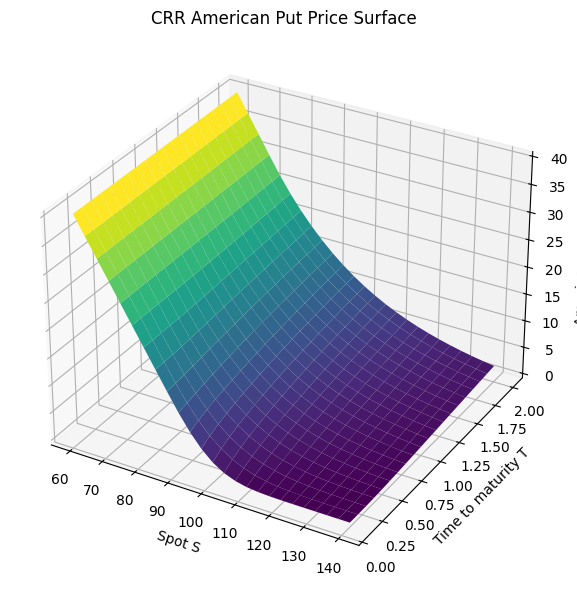

In [33]:
spots,maturities,prices = price_grid()

S_mesh,T_mesh = np.meshgrid(spots,maturities)

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111,projection="3d")

ax.plot_surface(S_mesh,T_mesh,prices,cmap="viridis",linewidth=0)

ax.set_xlabel("Spot S")
ax.set_ylabel("Time to maturity T")
ax.set_zlabel("American put price")

ax.set_title("CRR American Put Price Surface")

plt.tight_layout()
plt.show()

In [34]:
plt.savefig("american_put_price_surface.png",dpi=300,bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [35]:
def crr_put_with_boundary(S0,K,T,r,sigma,steps):
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp(r * dt) - d) / (u - d)
    disc = math.exp(-r * dt)

    j = np.arange(steps + 1)
    stock = S0 * (u ** j) * (d ** (steps - j))
    value = np.maximum(K - stock,0.0)
    boundary = []

    for i in range(steps - 1,-1,-1):
        continuation = disc * (p * value[1:i + 2] + (1.0 - p) * value[0:i + 1])

        j = np.arange(i + 1)
        stock = S0 * (u ** j) * (d ** (i - j))
        exercise = np.maximum(K - stock,0.0)

        exercise_now = exercise > continuation + 1e-10

        if np.any(exercise_now):
            boundary_stock = float(np.max(stock[exercise_now]))
            boundary.append((i * dt,boundary_stock))

        value = np.maximum(continuation,exercise)

    boundary.reverse()
    return float(value[0]),boundary

In [36]:
price,boundary = crr_put_with_boundary(100,100,1.0,0.05,0.25,500)

print(f"American Put Price: {price:.6f}")
print(f"Boundary Points: {len(boundary)}")

American Put Price: 7.972371
Boundary Points: 474


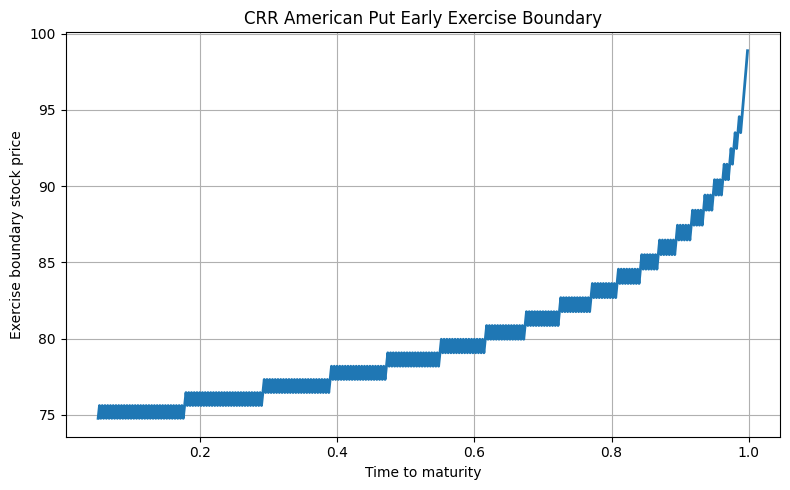

In [37]:
price,boundary = crr_put_with_boundary(
    100,100,1.0,0.05,0.25,500
)

times = [t for t,s in boundary]
stocks = [s for t,s in boundary]

plt.figure(figsize=(8,5))
plt.plot(times,stocks,linewidth=2)

plt.xlabel("Time to maturity")
plt.ylabel("Exercise boundary stock price")
plt.title("CRR American Put Early Exercise Boundary")

plt.grid(True)
plt.tight_layout()

plt.savefig("american_put_boundary.png",dpi=600,bbox_inches="tight")
plt.show()

In [38]:
plt.savefig("american_put_boundary.png",dpi=600,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Early Exercise Boundary Interpretation

The graph shows the **optimal early exercise boundary** for an American put option using the CRR Binomial Tree model. The horizontal axis represents the **time to maturity**, while the vertical axis represents the **stock price at which early exercise becomes optimal**.

At any point **below the boundary**, it is financially better to **exercise the put option immediately**. At stock prices **above the boundary**, it is better to **continue holding the option**, since there is still a chance that the stock price may fall further before expiration, increasing the option's value.

The boundary increases as the option approaches maturity. Early in the option's life, the boundary is relatively low, meaning investors usually prefer to keep the option rather than exercise it because there is sufficient time for the stock price to move further in their favor. As the expiration date gets closer, the opportunity for additional gains becomes smaller, so the threshold for exercising the option moves upward.

### early exercise makes financial sense

For an American put option, early exercise becomes beneficial when the stock price falls significantly below the strike price. Exercising immediately allows the holder to lock in a larger payoff instead of waiting for expiration when there is little remaining time for the option value to increase.

Near maturity, the remaining time value of the option becomes very small. If the option is already deep in the money, waiting provides limited additional benefit while delaying the receipt of cash. By exercising early, the investor receives the payoff immediately and can reinvest the proceeds at the risk free interest rate. This makes early exercise financially optimal in certain regions, which is exactly what the exercise boundary identifies.

### Observation from the Graph

The staircase shape of the boundary is expected because the CRR model uses a finite number of time steps. As the number of steps increases, the staircase becomes smoother and provides a more accurate approximation of the true continuous early exercise boundary. The graph clearly demonstrates that the region where early exercise is optimal expands as the option approaches expiration, which is a characteristic feature of American put options.
